# 高级表格模型与深度学习比较

本 Notebook 在统一数据切分下比较 CatBoost、LightGBM、XGBoost 和基于类别嵌入的 PyTorch 深度网络。所有代码、变量、数据列名和图表文字均为英文；中文只用于 Markdown 解释。

## tl;dr

- 三种梯度提升模型的等权融合在独立 holdout 上表现最好：ROC-AUC **0.940314**、Log Loss **0.229087**、Average Precision **0.749998**。
- 最佳单模是 XGBoost，ROC-AUC **0.940255**；CatBoost 和 LightGBM 分别为 0.940118 和 0.940113。
- PyTorch 类别嵌入网络在第 7 个 epoch 达到最佳 tuning ROC-AUC，holdout ROC-AUC 为 **0.938041**。它明显优于常数基线，但暂未超过树模型。
- 将神经网络加入四模型等权融合后 ROC-AUC 降至 0.940112，因此当前不建议把它纳入最终等权提交。
- CPU 时间差异明显：CatBoost 每个候选约需 126–131 秒，LightGBM 约 4 秒，XGBoost 约 8–12 秒。后续大规模调参优先选择 LightGBM/XGBoost。
- 当前最合理的竞赛方向是以 XGBoost、LightGBM、CatBoost 为主体进行折外预测和加权融合；深度模型作为误差多样性实验，而不是主模型。


## 实验设计

- 20% 数据作为最终 holdout，只用于一次模型比较。
- 剩余数据中划出独立 tuning 集，用于早停和候选参数选择。
- 为控制 CPU 运行时间，默认训练样本最多 140,000 行、tuning 样本最多 40,000 行。
- 三种梯度提升模型各比较两组参数；深度网络使用验证 AUC 早停。
- 主指标暂定 ROC-AUC，同时报告 Log Loss、Average Precision 和 Brier Score。
- 深度网络使用类别 embedding，而不是简单地把所有类别 One-Hot 后输入神经网络。

## 1. Setup

In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

from copy import deepcopy
from pathlib import Path
from time import perf_counter
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TARGET = "Will_Buy_EV"
ID_COLUMN = "id"
HOLDOUT_SIZE = 0.20
TREE_TRAIN_SIZE = 140_000
TUNING_SIZE = 40_000
DEEP_BATCH_SIZE = 2048
DEEP_MAX_EPOCHS = 12
DEEP_PATIENCE = 3

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.set_num_threads(1)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"

COLORS = {
    "blue": "#3569A8",
    "gold": "#D6A72C",
    "orange": "#D97941",
    "olive": "#7A8B45",
    "pink": "#B65C7A",
    "gray": "#A8AFB8",
    "charcoal": "#30343B",
}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titleweight": "bold", "grid.color": "#D9DDE2"})

print("Python environment ready")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python environment ready
Torch version: 2.14.0+cpu
CUDA available: False


## 2. Data Split

In [2]:
train_data = pd.read_csv(DATA_DIR / "train.csv")
target = train_data[TARGET].map({"No": 0, "Yes": 1})
features = train_data.drop(columns=[TARGET])

X_development_pool, X_holdout, y_development_pool, y_holdout = train_test_split(
    features,
    target,
    test_size=HOLDOUT_SIZE,
    random_state=RANDOM_STATE,
    stratify=target,
)

X_train_pool, X_tuning, y_train_pool, y_tuning = train_test_split(
    X_development_pool,
    y_development_pool,
    test_size=TUNING_SIZE,
    random_state=RANDOM_STATE + 1,
    stratify=y_development_pool,
)

if len(X_train_pool) > TREE_TRAIN_SIZE:
    X_train, _, y_train, _ = train_test_split(
        X_train_pool,
        y_train_pool,
        train_size=TREE_TRAIN_SIZE,
        random_state=RANDOM_STATE + 2,
        stratify=y_train_pool,
    )
else:
    X_train, y_train = X_train_pool.copy(), y_train_pool.copy()

split_summary = pd.DataFrame({
    "Rows": [len(features), len(X_train), len(X_tuning), len(X_holdout)],
    "Positive_Rate": [target.mean(), y_train.mean(), y_tuning.mean(), y_holdout.mean()],
}, index=["Full_Train", "Model_Train", "Tuning", "Holdout"])
display(split_summary.round(6))

,Rows,Positive_Rate
Full_Train,668665,0.174645
Model_Train,140000,0.174643
Tuning,40000,0.174650
Holdout,133733,0.174646


`Model_Train` 用于拟合候选模型，`Tuning` 用于早停和选择每个模型家族的参数，`Holdout` 只在所有选择完成后评估。这样可以避免反复观察 holdout 后继续调参。

## 3. Shared Feature Engineering

In [3]:
def engineer_features(data):
    transformed = data.copy().drop(columns=[ID_COLUMN], errors="ignore")
    transformed["Total_Charging_Stations"] = (
        transformed["Charging_Stations_Near_Home"] + transformed["Charging_Stations_Near_Work"]
    )
    transformed["Min_Charging_Stations"] = transformed[
        ["Charging_Stations_Near_Home", "Charging_Stations_Near_Work"]
    ].min(axis=1)
    transformed["Max_Charging_Stations"] = transformed[
        ["Charging_Stations_Near_Home", "Charging_Stations_Near_Work"]
    ].max(axis=1)
    transformed["Home_Work_Station_Gap"] = (
        transformed["Charging_Stations_Near_Home"] - transformed["Charging_Stations_Near_Work"]
    )
    transformed["Commute_Per_Station"] = (
        transformed["Daily_Commute_km"] / (transformed["Total_Charging_Stations"] + 1.0)
    )
    transformed["Log_Annual_Income"] = np.log1p(transformed["Annual_Income_USD"])
    transformed["Income_Per_Car"] = (
        transformed["Annual_Income_USD"] / transformed["Number_of_Cars_Owned"].clip(lower=1)
    )
    transformed["Income_Per_Commute"] = (
        transformed["Annual_Income_USD"] / transformed["Daily_Commute_km"].clip(lower=1)
    )
    transformed["Environment_Income_Interaction"] = (
        transformed["Environmental_Concern_Level"] * transformed["Log_Annual_Income"]
    )
    transformed["Environment_Charging_Interaction"] = (
        transformed["Environmental_Concern_Level"] * transformed["Total_Charging_Stations"]
    )
    transformed["Age_Band"] = pd.cut(
        transformed["Age"],
        bins=[-np.inf, 29, 39, 49, 59, np.inf],
        labels=["25_29", "30_39", "40_49", "50_59", "60_plus"],
    ).astype(str)
    transformed["Income_Band"] = pd.cut(
        transformed["Annual_Income_USD"],
        bins=[-np.inf, 50_000, 75_000, 100_000, 125_000, np.inf],
        labels=["under_50k", "50k_75k", "75k_100k", "100k_125k", "125k_plus"],
    ).astype(str)
    transformed["Commute_Band"] = pd.cut(
        transformed["Daily_Commute_km"],
        bins=[-np.inf, 10, 25, 50, 75, np.inf],
        labels=["under_10", "10_25", "25_50", "50_75", "75_plus"],
    ).astype(str)
    transformed["Charging_Context"] = (
        transformed["Home_Charging_Possible"].astype(str)
        + "_"
        + transformed["Subsidy_Available"].astype(str)
    )
    return transformed.replace([np.inf, -np.inf], np.nan)


X_train_engineered = engineer_features(X_train)
X_tuning_engineered = engineer_features(X_tuning)
X_holdout_engineered = engineer_features(X_holdout)

categorical_columns = X_train_engineered.select_dtypes(exclude=np.number).columns.tolist()
numeric_columns = X_train_engineered.select_dtypes(include=np.number).columns.tolist()

print("Engineered columns:", X_train_engineered.shape[1])
print("Numeric columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))

Engineered columns: 27
Numeric columns: 17
Categorical columns: 10


## 4. Tree Model Preprocessing

In [4]:
tree_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), selector(dtype_include=np.number)),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]),
        selector(dtype_exclude=np.number),
    ),
])

X_train_encoded = tree_preprocessor.fit_transform(X_train_engineered)
X_tuning_encoded = tree_preprocessor.transform(X_tuning_engineered)
X_holdout_encoded = tree_preprocessor.transform(X_holdout_engineered)

X_train_catboost = X_train_engineered.copy()
X_tuning_catboost = X_tuning_engineered.copy()
X_holdout_catboost = X_holdout_engineered.copy()
for column in categorical_columns:
    X_train_catboost[column] = X_train_catboost[column].fillna("Missing").astype(str)
    X_tuning_catboost[column] = X_tuning_catboost[column].fillna("Missing").astype(str)
    X_holdout_catboost[column] = X_holdout_catboost[column].fillna("Missing").astype(str)

print("Encoded matrix shape:", X_train_encoded.shape)

Encoded matrix shape: (140000, 53)


## 5. Candidate Search for Boosting Models

In [5]:
def probability_metrics(y_true, probabilities):
    return {
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "Log_Loss": log_loss(y_true, probabilities),
        "Average_Precision": average_precision_score(y_true, probabilities),
        "Brier_Score": brier_score_loss(y_true, probabilities),
    }


def select_best_candidate(model_family, candidates, fit_function, prediction_data):
    rows = []
    fitted_models = []
    for candidate_name, model in candidates:
        start_time = perf_counter()
        fitted_model = fit_function(model)
        fit_seconds = perf_counter() - start_time
        probabilities = fitted_model.predict_proba(prediction_data)[:, 1]
        rows.append({
            "Model_Family": model_family,
            "Candidate": candidate_name,
            "Tuning_ROC_AUC": roc_auc_score(y_tuning, probabilities),
            "Tuning_Log_Loss": log_loss(y_tuning, probabilities),
            "Fit_Seconds": fit_seconds,
        })
        fitted_models.append(fitted_model)

    result_table = pd.DataFrame(rows).sort_values("Tuning_ROC_AUC", ascending=False)
    best_index = result_table.index[0]
    return result_table, fitted_models[best_index]

In [6]:
catboost_candidates = [
    (
        "depth_6",
        CatBoostClassifier(
            iterations=600,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=5.0,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            thread_count=1,
            verbose=False,
        ),
    ),
    (
        "depth_8",
        CatBoostClassifier(
            iterations=500,
            depth=8,
            learning_rate=0.05,
            l2_leaf_reg=8.0,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            thread_count=1,
            verbose=False,
        ),
    ),
]


def fit_catboost(model):
    return model.fit(
        X_train_catboost,
        y_train,
        cat_features=categorical_columns,
        eval_set=(X_tuning_catboost, y_tuning),
        early_stopping_rounds=60,
        use_best_model=True,
        verbose=False,
    )


catboost_search_results, best_catboost = select_best_candidate(
    "CatBoost",
    catboost_candidates,
    fit_catboost,
    X_tuning_catboost,
)
display(catboost_search_results.round(6))

,Model_Family,Candidate,Tuning_ROC_AUC,Tuning_Log_Loss,Fit_Seconds
0,CatBoost,depth_6,0.940404,0.228824,126.253932
1,CatBoost,depth_8,0.940109,0.229233,130.902454


In [7]:
lightgbm_candidates = [
    (
        "leaves_31",
        LGBMClassifier(
            n_estimators=800,
            learning_rate=0.03,
            num_leaves=31,
            min_child_samples=50,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            n_jobs=1,
            random_state=RANDOM_STATE,
            verbosity=-1,
        ),
    ),
    (
        "leaves_63",
        LGBMClassifier(
            n_estimators=600,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=80,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=5.0,
            n_jobs=1,
            random_state=RANDOM_STATE,
            verbosity=-1,
        ),
    ),
]


def fit_lightgbm(model):
    return model.fit(
        X_train_encoded,
        y_train,
        eval_set=[(X_tuning_encoded, y_tuning)],
        eval_metric="auc",
        callbacks=[early_stopping(60, verbose=False), log_evaluation(0)],
    )


lightgbm_search_results, best_lightgbm = select_best_candidate(
    "LightGBM",
    lightgbm_candidates,
    fit_lightgbm,
    X_tuning_encoded,
)
display(lightgbm_search_results.round(6))

,Model_Family,Candidate,Tuning_ROC_AUC,Tuning_Log_Loss,Fit_Seconds
0,LightGBM,leaves_31,0.940595,0.228492,4.326778
1,LightGBM,leaves_63,0.940390,0.228784,3.547977


In [8]:
xgboost_candidates = [
    (
        "depth_5",
        XGBClassifier(
            n_estimators=800,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=5,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=2.0,
            tree_method="hist",
            eval_metric="auc",
            early_stopping_rounds=60,
            n_jobs=1,
            random_state=RANDOM_STATE,
        ),
    ),
    (
        "depth_7",
        XGBClassifier(
            n_estimators=600,
            learning_rate=0.04,
            max_depth=7,
            min_child_weight=10,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=5.0,
            tree_method="hist",
            eval_metric="auc",
            early_stopping_rounds=60,
            n_jobs=1,
            random_state=RANDOM_STATE,
        ),
    ),
]


def fit_xgboost(model):
    return model.fit(
        X_train_encoded,
        y_train,
        eval_set=[(X_tuning_encoded, y_tuning)],
        verbose=False,
    )


xgboost_search_results, best_xgboost = select_best_candidate(
    "XGBoost",
    xgboost_candidates,
    fit_xgboost,
    X_tuning_encoded,
)
display(xgboost_search_results.round(6))

,Model_Family,Candidate,Tuning_ROC_AUC,Tuning_Log_Loss,Fit_Seconds
0,XGBoost,depth_5,0.940649,0.228419,11.772613
1,XGBoost,depth_7,0.940528,0.228499,8.304285


每个模型家族只使用 tuning 集选择两组候选中的较优者。候选数量较少是有意的：先测试复杂度方向，再决定是否值得扩大搜索，而不是在一次数据切分上进行大规模盲搜。

## 6. Category Embedding Neural Network

In [9]:
numeric_imputer = SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()

train_numeric = numeric_scaler.fit_transform(
    numeric_imputer.fit_transform(X_train_engineered[numeric_columns])
).astype(np.float32)
tuning_numeric = numeric_scaler.transform(
    numeric_imputer.transform(X_tuning_engineered[numeric_columns])
).astype(np.float32)
holdout_numeric = numeric_scaler.transform(
    numeric_imputer.transform(X_holdout_engineered[numeric_columns])
).astype(np.float32)

category_maps = {}
category_cardinalities = []
train_categorical_parts = []
tuning_categorical_parts = []
holdout_categorical_parts = []

for column in categorical_columns:
    train_values = X_train_engineered[column].fillna("Missing").astype(str)
    tuning_values = X_tuning_engineered[column].fillna("Missing").astype(str)
    holdout_values = X_holdout_engineered[column].fillna("Missing").astype(str)

    mapping = {value: index + 1 for index, value in enumerate(sorted(train_values.unique()))}
    category_maps[column] = mapping
    category_cardinalities.append(len(mapping) + 1)

    train_categorical_parts.append(train_values.map(mapping).fillna(0).to_numpy(dtype=np.int64))
    tuning_categorical_parts.append(tuning_values.map(mapping).fillna(0).to_numpy(dtype=np.int64))
    holdout_categorical_parts.append(holdout_values.map(mapping).fillna(0).to_numpy(dtype=np.int64))

train_categorical = np.column_stack(train_categorical_parts)
tuning_categorical = np.column_stack(tuning_categorical_parts)
holdout_categorical = np.column_stack(holdout_categorical_parts)

print("Numeric tensor shape:", train_numeric.shape)
print("Categorical tensor shape:", train_categorical.shape)
print("Category cardinalities:", category_cardinalities)

Numeric tensor shape: (140000, 17)
Categorical tensor shape: (140000, 10)
Category cardinalities: [4, 4, 5, 3, 3, 4, 6, 6, 6, 5]


In [10]:
class CategoryEmbeddingNetwork(nn.Module):
    def __init__(self, numeric_feature_count, category_cardinalities):
        super().__init__()
        embedding_dimensions = [min(16, max(2, int(np.ceil(np.sqrt(cardinality))))) for cardinality in category_cardinalities]
        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinality, dimension)
            for cardinality, dimension in zip(category_cardinalities, embedding_dimensions)
        ])
        total_input_size = numeric_feature_count + sum(embedding_dimensions)
        self.network = nn.Sequential(
            nn.Linear(total_input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 1),
        )

    def forward(self, numeric_inputs, categorical_inputs):
        embedded_parts = [
            embedding(categorical_inputs[:, index])
            for index, embedding in enumerate(self.embeddings)
        ]
        combined = torch.cat([numeric_inputs, *embedded_parts], dim=1)
        return self.network(combined).squeeze(1)


def make_loader(numeric_data, categorical_data, labels=None, shuffle=False):
    tensors = [
        torch.from_numpy(numeric_data),
        torch.from_numpy(categorical_data),
    ]
    if labels is not None:
        tensors.append(torch.from_numpy(np.asarray(labels, dtype=np.float32)))
    return DataLoader(
        TensorDataset(*tensors),
        batch_size=DEEP_BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
    )


train_loader = make_loader(train_numeric, train_categorical, y_train, shuffle=True)
tuning_loader = make_loader(tuning_numeric, tuning_categorical, y_tuning, shuffle=False)
holdout_loader = make_loader(holdout_numeric, holdout_categorical, None, shuffle=False)

In [11]:
def predict_neural_network(model, data_loader):
    model.eval()
    prediction_parts = []
    with torch.no_grad():
        for batch in data_loader:
            numeric_batch, categorical_batch = batch[:2]
            logits = model(numeric_batch, categorical_batch)
            prediction_parts.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(prediction_parts)


deep_model = CategoryEmbeddingNetwork(
    numeric_feature_count=train_numeric.shape[1],
    category_cardinalities=category_cardinalities,
)
optimizer = torch.optim.AdamW(deep_model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_function = nn.BCEWithLogitsLoss()

best_state = None
best_tuning_auc = -np.inf
epochs_without_improvement = 0
deep_history = []
deep_start = perf_counter()

for epoch in range(1, DEEP_MAX_EPOCHS + 1):
    deep_model.train()
    total_loss = 0.0
    total_examples = 0
    for numeric_batch, categorical_batch, target_batch in train_loader:
        optimizer.zero_grad()
        logits = deep_model(numeric_batch, categorical_batch)
        loss = loss_function(logits, target_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(target_batch)
        total_examples += len(target_batch)

    tuning_probabilities = predict_neural_network(deep_model, tuning_loader)
    tuning_auc = roc_auc_score(y_tuning, tuning_probabilities)
    epoch_loss = total_loss / total_examples
    deep_history.append({"Epoch": epoch, "Train_Loss": epoch_loss, "Tuning_ROC_AUC": tuning_auc})
    print(f"Epoch {epoch:02d} | loss={epoch_loss:.6f} | tuning_auc={tuning_auc:.6f}")

    if tuning_auc > best_tuning_auc + 1e-5:
        best_tuning_auc = tuning_auc
        best_state = deepcopy(deep_model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= DEEP_PATIENCE:
            print("Early stopping")
            break

deep_model.load_state_dict(best_state)
deep_fit_seconds = perf_counter() - deep_start
deep_history = pd.DataFrame(deep_history)
display(deep_history.round(6))

Epoch 01 | loss=0.347796 | tuning_auc=0.936553


Epoch 02 | loss=0.238704 | tuning_auc=0.937625


Epoch 03 | loss=0.236700 | tuning_auc=0.937856


Epoch 04 | loss=0.235576 | tuning_auc=0.937913


Epoch 05 | loss=0.235113 | tuning_auc=0.938013


...

Epoch 07 | loss=0.233593 | tuning_auc=0.938154


Epoch 08 | loss=0.233565 | tuning_auc=0.938149


Epoch 09 | loss=0.233092 | tuning_auc=0.938005


Epoch 10 | loss=0.233155 | tuning_auc=0.938026
Early stopping


,Epoch,Train_Loss,Tuning_ROC_AUC
0,1,0.347796,0.936553
1,2,0.238704,0.937625
2,3,0.236700,0.937856
3,4,0.235576,0.937913
4,5,0.235113,0.938013
5,6,0.234187,0.938142
6,7,0.233593,0.938154
7,8,0.233565,0.938149
8,9,0.233092,0.938005
9,10,0.233155,0.938026


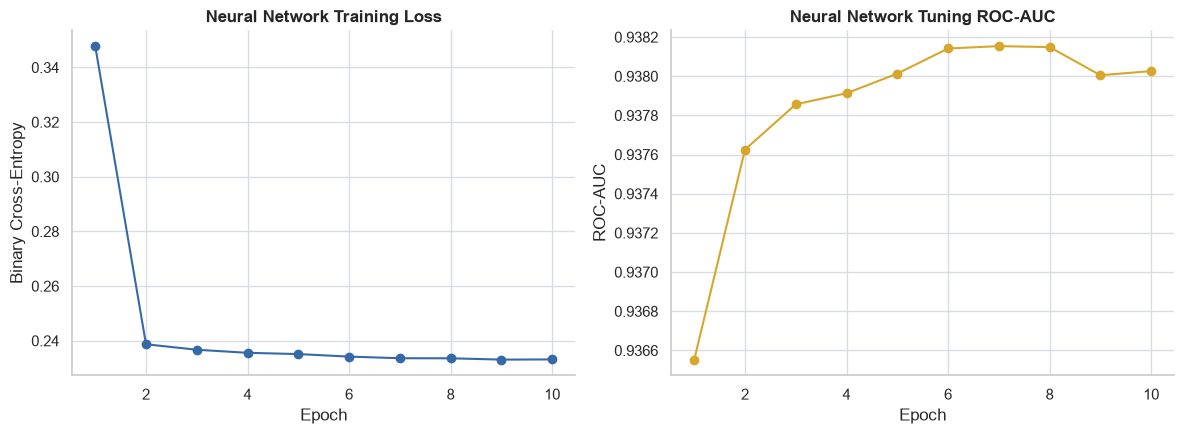

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(deep_history["Epoch"], deep_history["Train_Loss"], marker="o", color=COLORS["blue"])
axes[0].set(title="Neural Network Training Loss", xlabel="Epoch", ylabel="Binary Cross-Entropy")
axes[1].plot(deep_history["Epoch"], deep_history["Tuning_ROC_AUC"], marker="o", color=COLORS["gold"])
axes[1].set(title="Neural Network Tuning ROC-AUC", xlabel="Epoch", ylabel="ROC-AUC")
sns.despine()
plt.tight_layout()
plt.show()

## 7. Final Holdout Comparison

In [13]:
holdout_predictions = {
    "CatBoost": best_catboost.predict_proba(X_holdout_catboost)[:, 1],
    "LightGBM": best_lightgbm.predict_proba(X_holdout_encoded)[:, 1],
    "XGBoost": best_xgboost.predict_proba(X_holdout_encoded)[:, 1],
    "Category Embedding NN": predict_neural_network(deep_model, holdout_loader),
}

holdout_predictions["GBDT Equal Blend"] = np.mean(
    [holdout_predictions["CatBoost"], holdout_predictions["LightGBM"], holdout_predictions["XGBoost"]],
    axis=0,
)
holdout_predictions["All Model Equal Blend"] = np.mean(list(holdout_predictions.values())[:4], axis=0)

comparison_rows = []
for model_name, probabilities in holdout_predictions.items():
    comparison_rows.append({"Model": model_name, **probability_metrics(y_holdout, probabilities)})

holdout_comparison = pd.DataFrame(comparison_rows).set_index("Model").sort_values("ROC_AUC", ascending=False)
display(holdout_comparison.round(6))

,ROC_AUC,Log_Loss,Average_Precision,Brier_Score
Model,,,,
GBDT Equal Blend,0.940314,0.229087,0.749998,0.072157
XGBoost,0.940255,0.229176,0.749876,0.072166
CatBoost,0.940118,0.229394,0.749020,0.072287
LightGBM,0.940113,0.229530,0.749342,0.072259
All Model Equal Blend,0.940112,0.229487,0.748896,0.072312
Category Embedding NN,0.938041,0.233314,0.739773,0.073684


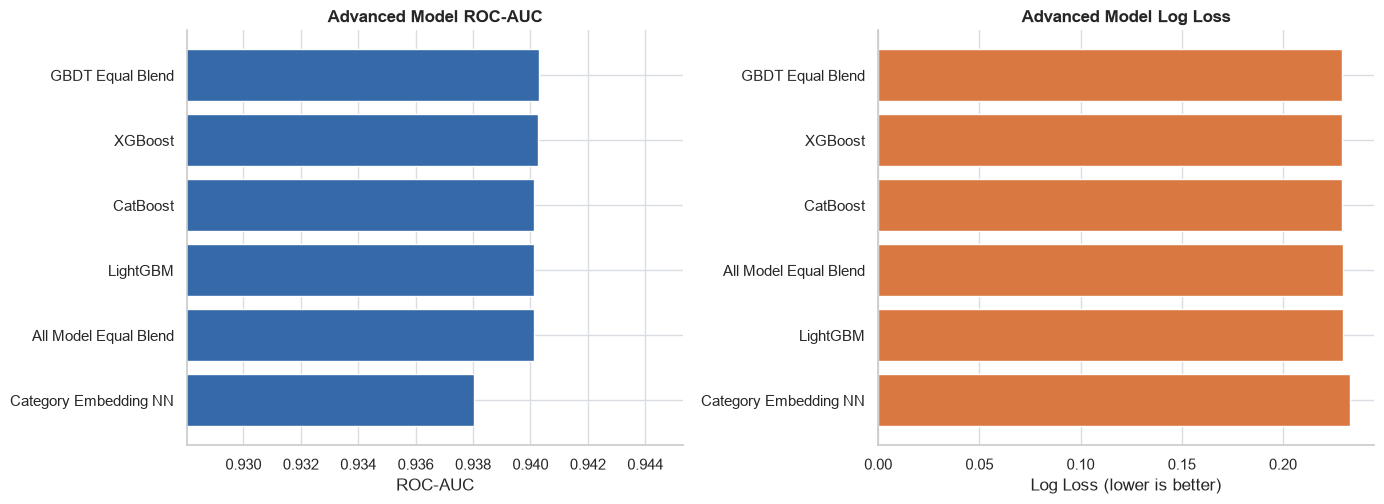

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

roc_values = holdout_comparison["ROC_AUC"].sort_values()
axes[0].barh(roc_values.index, roc_values.values, color=COLORS["blue"])
axes[0].set_xlim(max(0.5, roc_values.min() - 0.01), min(1.0, roc_values.max() + 0.005))
axes[0].set(title="Advanced Model ROC-AUC", xlabel="ROC-AUC", ylabel="")

log_loss_values = holdout_comparison["Log_Loss"].sort_values(ascending=False)
axes[1].barh(log_loss_values.index, log_loss_values.values, color=COLORS["orange"])
axes[1].set(title="Advanced Model Log Loss", xlabel="Log Loss (lower is better)", ylabel="")

sns.despine()
plt.tight_layout()
plt.show()

## 使用建议

1. 树模型通常仍是这类表格数据的第一选择；深度模型的价值主要在于提供结构不同的预测误差，用于集成。
2. 如果深度模型单模分数略低但与树模型预测不完全相关，加入简单平均仍可能改善结果。
3. 当前参数搜索预算较小；只有当某个模型家族明显领先时，才值得对该家族扩大交叉验证调参。
4. 没有 GPU 时不建议直接扩大网络宽度和 epoch 数；更有效的方向通常是改进类别 embedding、数值特征分桶和学习率策略。
5. `pytorch-tabular` 尚未安装，因为它要求将 Pandas 3.0.6 降级到 2.3.x。当前手写 PyTorch 网络不需要修改现有数据环境。